# Universal Generator Sokoban Evaluation (Bank vs Universal)

Compare dumped `solve_attempts/*.joblib` solve traces for:
- bank baseline (`k841`, `k84`, `k8`), and
- universal propositional generator variants (`ugen_raw`, `ugen_ft`, `ugen_con`).

The notebook is defensive: it runs even if some groups are missing, and will still analyze available logs.


In [1]:
from pathlib import Path
from collections import defaultdict
import statistics
import math

import joblib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown

from carl.planners.base import Experience
from carl.solver.nodes import SearchTreeNode


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'solve_attempts').exists():
            return p
    raise RuntimeError('Could not find repo root.')

ROOT = find_repo_root()
SOLVE_DIR = ROOT / 'solve_attempts'
print('Repo root:', ROOT)
print('Solve dir:', SOLVE_DIR)


Repo root: /home/mtyrolski/dev/carl/CaRL
Solve dir: /home/mtyrolski/dev/carl/CaRL/solve_attempts


In [3]:
GROUP_PATTERNS = {
    # Bank mode baselines
    'bank_k841': ['solved_problems_k841_12x12x4_batch_*.joblib'],
    'bank_k84': ['solved_problems_k84_12x12x4_batch_*.joblib'],
    'bank_k8': ['solved_problems_k8_12x12x4_batch_*.joblib'],
    # Universal mode variants (from new config tags)
    'ugen_raw': ['solved_problems_ugen_raw_12x12x4_batch_*.joblib'],
    'ugen_ft': ['solved_problems_ugen_ft_12x12x4_batch_*.joblib'],
    'ugen_con': ['solved_problems_ugen_con_12x12x4_batch_*.joblib'],
}

BUDGETS = [25, 50, 100, 200, 300, 500]


In [4]:
def flatten_experiences(obj, limit=None):
    out = []
    stack = [obj]
    while stack:
        cur = stack.pop()
        if isinstance(cur, Experience):
            out.append(cur)
            if limit is not None and len(out) >= limit:
                break
        elif isinstance(cur, list):
            stack.extend(cur)
    return out


def load_group_experiences(group_name, patterns, max_experiences=None):
    exps = []
    files = []
    for pat in patterns:
        for file in sorted(SOLVE_DIR.glob(pat)):
            files.append(file)
            exps.extend(flatten_experiences(joblib.load(file), None if max_experiences is None else max_experiences - len(exps)))
            if max_experiences is not None and len(exps) >= max_experiences:
                break
        if max_experiences is not None and len(exps) >= max_experiences:
            break
    return files, exps[:max_experiences] if max_experiences is not None else exps


def iter_solving_node_path(solving_node: SearchTreeNode | None):
    if solving_node is None:
        return []
    nodes = []
    cur = solving_node
    while cur is not None:
        nodes.append(cur)
        cur = cur.parent_node
    return list(reversed(nodes))


def realized_segment_lengths(exp: Experience):
    # Prefer explicit metric from new solver path.
    lengths = getattr(exp.search_info, 'realized_segment_lengths', None)
    if lengths:
        return list(lengths)
    # Fallback: reconstruct from solving node low-level paths if available.
    nodes = iter_solving_node_path(exp.search_info.solving_node)
    out = []
    for node in nodes[1:]:
        ll = node.low_level_path or []
        out.append(len(ll))
    return out


def fallback_validator_rejection_rate(exp: Experience):
    info = exp.search_info
    rate = getattr(info, 'validator_rejection_rate', None)
    if rate is not None:
        return rate
    valid = info.high_level_nodes_valid or 0
    rej = info.high_level_nodes_unreachable or 0
    denom = valid + rej
    return (rej / denom) if denom else None


def fallback_runtime(exp: Experience):
    return getattr(exp.search_info, 'runtime_seconds', None)


def fallback_backtracking_ratio(exp: Experience):
    return getattr(exp.search_info, 'backtracking_ratio', None)


def fallback_diversity(exp: Experience):
    return getattr(exp.search_info, 'proposal_diversity_unique_ratio', None)


def solve_rate_at_budget(exps, budget):
    if not exps:
        return None
    solved = 0
    for exp in exps:
        ll_nodes = exp.search_info.low_level_nodes_visited
        if exp.solution.solved and ll_nodes is not None and ll_nodes <= budget:
            solved += 1
    return solved / len(exps)


def mean_or_none(values):
    vals = [v for v in values if v is not None]
    if not vals:
        return None
    return float(sum(vals) / len(vals))


def summarize_group(exps):
    if not exps:
        return {}
    solved = [e for e in exps if e.solution.solved]
    ll_nodes = [e.search_info.low_level_nodes_visited for e in exps if e.search_info.low_level_nodes_visited is not None]
    runtimes = [fallback_runtime(e) for e in exps]
    reject_rates = [fallback_validator_rejection_rate(e) for e in exps]
    backtracking = [fallback_backtracking_ratio(e) for e in exps]
    diversity = [fallback_diversity(e) for e in exps]
    seg_lengths = [l for e in solved for l in realized_segment_lengths(e)]
    return {
        'n': len(exps),
        'solved': len(solved),
        'solve_rate': len(solved) / len(exps),
        'mean_nodes': float(round(statistics.mean(ll_nodes), 2)) if ll_nodes else None,
        'mean_runtime_s': mean_or_none(runtimes),
        'mean_validator_rejection_rate': mean_or_none(reject_rates),
        'mean_backtracking_ratio': mean_or_none(backtracking),
        'mean_proposal_diversity': mean_or_none(diversity),
        'segment_lengths_count': len(seg_lengths),
        'segment_len_mean': float(round(statistics.mean(seg_lengths), 2)) if seg_lengths else None,
    }


In [5]:
MAX_EXPS_PER_GROUP = 500

groups = {}
for name, patterns in GROUP_PATTERNS.items():
    files, exps = load_group_experiences(name, patterns, max_experiences=MAX_EXPS_PER_GROUP)
    groups[name] = {'files': files, 'experiences': exps}
    print(f"{name:>10}: files={len(files):2d}, experiences={len(exps):4d}")

available_groups = [name for name, v in groups.items() if v['experiences']]
missing_groups = [name for name, v in groups.items() if not v['experiences']]
print("\nAvailable groups:", available_groups)
print("Missing groups:", missing_groups)


 bank_k841: files=10, experiences= 500
  bank_k84: files=10, experiences= 500
   bank_k8: files=10, experiences= 500
  ugen_raw: files= 0, experiences=   0
   ugen_ft: files= 0, experiences=   0
  ugen_con: files= 0, experiences=   0

Available groups: ['bank_k841', 'bank_k84', 'bank_k8']
Missing groups: ['ugen_raw', 'ugen_ft', 'ugen_con']


In [6]:
summary_rows = []
for name in available_groups:
    summary = summarize_group(groups[name]['experiences'])
    summary_rows.append((name, summary))

for name, summary in summary_rows:
    print(f"\n{name}")
    for k, v in summary.items():
        print(f"  {k}: {v}")



bank_k841
  n: 500
  solved: 460
  solve_rate: 0.92
  mean_nodes: 99.68
  mean_runtime_s: None
  mean_validator_rejection_rate: 0.033534962877028396
  mean_backtracking_ratio: None
  mean_proposal_diversity: None
  segment_lengths_count: 3476
  segment_len_mean: 6.23

bank_k84
  n: 500
  solved: 453
  solve_rate: 0.906
  mean_nodes: 87.6
  mean_runtime_s: None
  mean_validator_rejection_rate: 0.034180458345663946
  mean_backtracking_ratio: None
  mean_proposal_diversity: None
  segment_lengths_count: 3390
  segment_len_mean: 6.24

bank_k8
  n: 500
  solved: 400
  solve_rate: 0.8
  mean_nodes: 237.93
  mean_runtime_s: None
  mean_validator_rejection_rate: 0.11435282082803565
  mean_backtracking_ratio: None
  mean_proposal_diversity: None
  segment_lengths_count: 2808
  segment_len_mean: 6.25


## Solve Curves (SolveRate@budget)

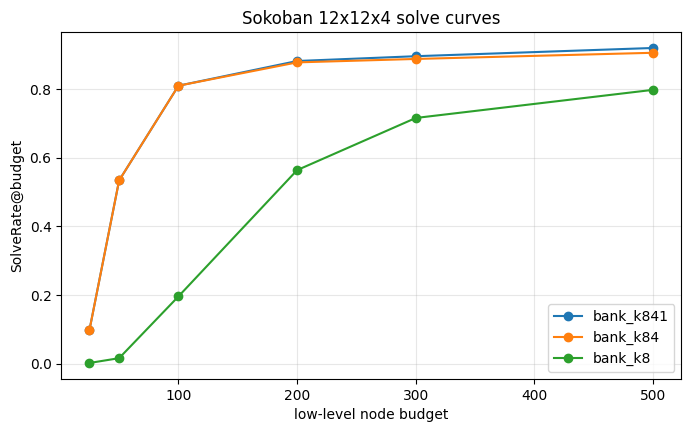

In [7]:
if available_groups:
    plt.figure(figsize=(8, 4.5))
    for name in available_groups:
        exps = groups[name]['experiences']
        ys = [solve_rate_at_budget(exps, b) for b in BUDGETS]
        plt.plot(BUDGETS, ys, marker='o', label=name)
    plt.xlabel('low-level node budget')
    plt.ylabel('SolveRate@budget')
    plt.title('Sokoban 12x12x4 solve curves')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
else:
    print('No solve groups found.')


## Trajectory Characteristics (segment lengths, rejection, backtracking, diversity)

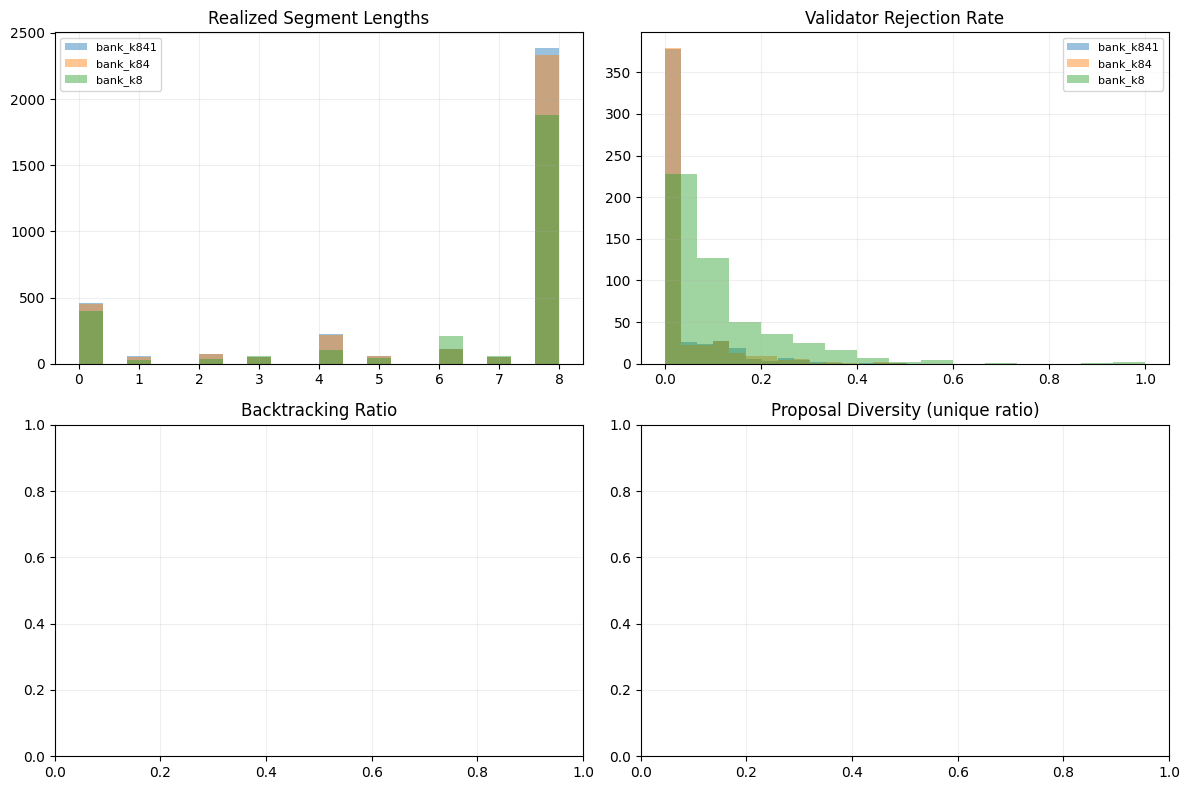

In [8]:
def gather_series(exps):
    solved = [e for e in exps if e.solution.solved]
    return {
        'segment_lengths': [l for e in solved for l in realized_segment_lengths(e)],
        'reject_rate': [fallback_validator_rejection_rate(e) for e in exps if fallback_validator_rejection_rate(e) is not None],
        'backtracking': [fallback_backtracking_ratio(e) for e in exps if fallback_backtracking_ratio(e) is not None],
        'diversity': [fallback_diversity(e) for e in exps if fallback_diversity(e) is not None],
    }

if available_groups:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()
    names = [('segment_lengths', 'Realized Segment Lengths'), ('reject_rate', 'Validator Rejection Rate'),
             ('backtracking', 'Backtracking Ratio'), ('diversity', 'Proposal Diversity (unique ratio)')]
    for ax, (key, title) in zip(axes, names):
        plotted = False
        for name in available_groups:
            series = gather_series(groups[name]['experiences'])[key]
            if not series:
                continue
            plotted = True
            bins = 20 if key == 'segment_lengths' else 15
            ax.hist(series, bins=bins, alpha=0.45, label=name)
        ax.set_title(title)
        if plotted:
            ax.legend(fontsize=8)
        ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


## Easy vs Hard Stratification (proxy)

A simple proxy split based on per-instance validator rejection rate:
- `easy`: rejection rate below group median
- `hard`: rejection rate at/above group median

This is a practical fallback when explicit state difficulty labels are unavailable.


In [9]:
def stratified_solve_rate(exps, budget):
    rates = [(fallback_validator_rejection_rate(e), e) for e in exps]
    rates = [(r, e) for r, e in rates if r is not None]
    if not rates:
        return None
    median = statistics.median([r for r, _ in rates])
    easy = [e for r, e in rates if r < median]
    hard = [e for r, e in rates if r >= median]
    return {
        'median_reject_rate': median,
        'easy_n': len(easy),
        'hard_n': len(hard),
        'easy_solve_rate_at_budget': solve_rate_at_budget(easy, budget) if easy else None,
        'hard_solve_rate_at_budget': solve_rate_at_budget(hard, budget) if hard else None,
    }

for name in available_groups:
    info = stratified_solve_rate(groups[name]['experiences'], budget=200)
    print(name, '->', info)


bank_k841 -> {'median_reject_rate': 0.0, 'easy_n': 0, 'hard_n': 500, 'easy_solve_rate_at_budget': None, 'hard_solve_rate_at_budget': 0.882}
bank_k84 -> {'median_reject_rate': 0.0, 'easy_n': 0, 'hard_n': 500, 'easy_solve_rate_at_budget': None, 'hard_solve_rate_at_budget': 0.878}
bank_k8 -> {'median_reject_rate': 0.07692307692307693, 'easy_n': 246, 'hard_n': 254, 'easy_solve_rate_at_budget': 0.6260162601626016, 'hard_solve_rate_at_budget': 0.5039370078740157}
